In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age','workclass','fnlwgt','education','education-num','marital-status',
           'occupation','relationship','race','sex','capital-gain','capital-loss',
           'hours-per-week','native-country','income']

df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Exploring Data(EDA)

In [ ]:
df.info()
df.describe()
df.isnull().sum()
df['income'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,count
income,
<=50K,24720
>50K,7841


Clean And Preprocess

In [ ]:
# Drop rows with missing values (or impute instead)
df = df.dropna()

# Encode target
df['income'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

# Separate features and target
X = df.drop('income', axis=1)
y = df['income']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

Train test/split and scaling


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train models


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

--- Logistic Regression ---
Accuracy: 0.8550591125441425
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513

--- Decision Tree ---
Accuracy: 0.8142177184093352
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4945
           1       0.61      0.64      0.62      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.76      0.75      6513
weighted avg       0.82      0.81      0.82      6513

--- Random Forest ---
Accuracy: 0.8615077537233226
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.75      0.64      0.69      1568

    accuracy           

Evaluate property

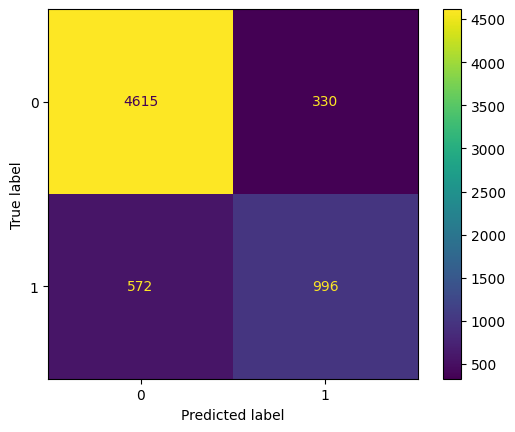

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.show()

Conclusion:

```
# This is formatted as code
```

Best model:
Random Forest gave the best overall performance, with the highest accuracy (86.2%) and the best F1-score (0.69) on the minority class (>50K). It edged out Logistic Regression slightly and clearly outperformed the single Decision Tree, which overfit and generalized worse (81.4% accuracy).

Confusion matrix (Random Forest):
Out of 6,513 test samples:

4,615 people earning <=50K were correctly classified (true negatives)
330 were incorrectly predicted as >50K (false positives)
572 people earning >50K were missed and predicted as <=50K (false negatives)
996 were correctly identified as >50K (true positives)

This shows the model is quite good at identifying the <=50K class (93% recall) but noticeably weaker at catching the >50K class (64% recall) — it misses about 1 in 3 high earners. This is expected given the class imbalance in the data (24,720 vs 7,841 — roughly 3:1).

Why the imbalance matters:
Because <=50K dominates the dataset, a model can score high accuracy just by favoring that class. The lower recall on >50K (0.64 for Random Forest) is the real story — precision/recall/F1 on the minority class matter more here than overall accuracy.

Takeaway:
"Random Forest was the strongest performer among the three models tested, likely due to its ability to capture non-linear feature interactions and reduce overfitting compared to a single Decision Tree. However, all models struggled somewhat with correctly identifying higher-income individuals due to class imbalance. Future improvements could include class balancing techniques (e.g., SMOTE or class weighting), hyperparameter tuning (e.g., GridSearchCV on Random Forest's n_estimators/max_depth), or trying gradient boosting models like XGBoost, which often perform even better on this dataset."